Imports

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from adjustText import adjust_text
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Constants and Global variables

In [3]:
# Constants
EXPRESSION_FILE = "C:\\Users\\Ana\\Documents\\Estágio\\Goglioti2018\\Goglioti2018_Cerebellum\\Expression_Genes_DESeq_Cerebellum.csv"
DEA_FILE = "C:\\Users\\Ana\\Documents\\Estágio\\Goglioti2018\\Goglioti2018_Cerebellum\\DEA_Genes_DESeq_Cerebellum.csv"
CLINICAL_DATA = "C:\\Users\\Ana\\Documents\\Estágio\\Goglioti2018\\Clinical_Data_Gogliotti18.csv"

# Variables
expression_df = None
dea_df = None
genes_of_interest = None

Expression - Import

In [4]:
expression_df = pd.read_csv(EXPRESSION_FILE)
expression_df.rename(columns = {'Unnamed: 0' : 'Gene'}, inplace = True)
expression_df.head()

,Gene,Cer_Ctrl_1,Cer_Ctrl_2,Cer_Ctrl_3,Cer_Ctrl_4,Cer_Ctrl_5,Cer_Ctrl_6,Cer_Ctrl_7,Cer_Ctrl_8,Cer_RTT_1,Cer_RTT_3,Cer_RTT_4,Cer_RTT_5,Cer_RTT_6,Cer_RTT_7
0,DDX11L2,368,124,124,134,219,287,125,723,45,210,418,190,155,230
1,WASH7P,534,1151,954,445,1134,594,1152,589,153,362,261,302,416,590
2,ENSG00000238009,0,0,1,3,3,0,6,6,0,0,3,0,0,0
3,ENSG00000268903,4,6,0,10,2,4,52,63,4,0,30,80,30,6
4,ENSG00000269981,9,2,0,23,8,1,59,88,8,6,21,43,22,3


DEA - Import

In [5]:
dea_df = pd.read_csv(DEA_FILE)
dea_df.rename(columns = {'Unnamed: 0' : 'Gene'}, inplace = True)
dea_df.dropna(subset =['padj'], inplace = True)
dea_df.head()

,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,PBX3,740.764186,1.496580,0.140519,10.650344,1.737212e-26,2.548316e-22
1,ADGRA2,327.802343,-0.789613,0.091343,-8.644524,5.402999e-18,3.962830e-14
2,WNK2,6545.365175,-0.602316,0.071297,-8.447977,2.963925e-17,1.449261e-13
3,GPC1,912.726714,-0.825804,0.098821,-8.356568,6.456949e-17,2.367924e-13
4,TSC2,11475.061165,-0.671586,0.085172,-7.885020,3.144845e-15,9.226346e-12


Volcano plot

Classification
Non-significant    11467
Up-regulated        1781
Down-regulated      1421
Name: count, dtype: int64
3202
Total tes:
18412


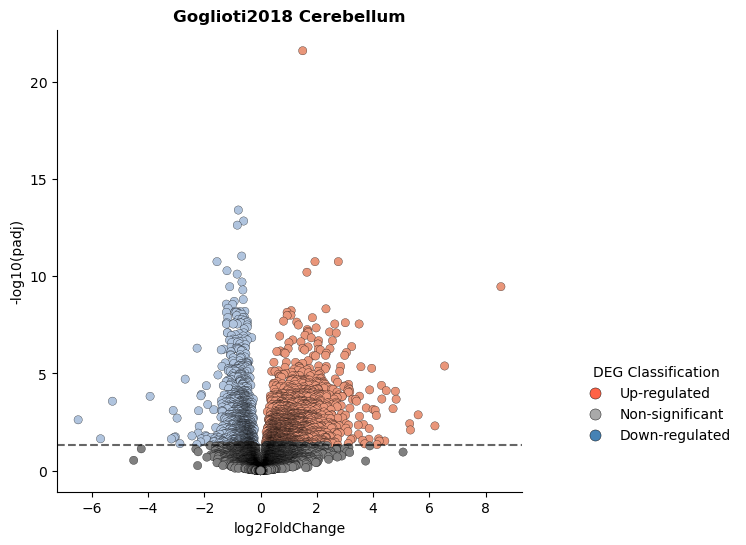

In [11]:

# Organizes the classification, according to the defined values
def organize_classification():
    dea_df['-log10(padj)'] = -np.log10(dea_df['padj'])

    dea_df['Classification'] = dea_df.apply(
        lambda row:
        'Up-regulated' if (row['log2FoldChange'] > 0 and row['padj'] < 0.05)
        else 'Down-regulated' if (row['log2FoldChange'] < -0 and row['padj'] < 0.05)
        else 'Non-significant',
        axis = 1
    )

# Sets the graph's reference lines and labels
def set_lines_and_labels(ax):
    ax.axhline(y = -np.log10(0.05), color = 'black', linestyle = '--', alpha = 0.6)

    ax.set_title('Goglioti2018 Cerebellum', fontweight = 'bold', fontsize = 12)
    ax.set_xlabel('log2FoldChange')
    ax.set_ylabel('-log10(padj)')

# Gets the genes with the biggest change in expression
def get_genes_of_interest():
    significant_df = dea_df[dea_df['Classification'] != 'Non-significant']
    top_up = significant_df.nlargest(5, 'log2FoldChange')['Gene'].tolist()
    top_down = significant_df.nsmallest(5, 'log2FoldChange')['Gene'].tolist()
    genes_of_interest = top_up + top_down

    dea_df['Classification'] = np.where(dea_df['Gene'].isin(genes_of_interest), 
                                        'GOI_' + dea_df['Classification'],
                                        dea_df['Classification'])
    
    return genes_of_interest

# Sets the genes of interest's names on the graph
def set_genes_of_interest_legend(ax):
    global genes_of_interest
    genes_of_interest = get_genes_of_interest()
    texts = []
    for i, row in dea_df.iterrows():
        if row['Gene'] in genes_of_interest:
            texts.append(ax.text(row['log2FoldChange'], row['-log10(padj)'], row['Gene'],
                         fontsize = 7, color = 'black', fontweight = 'semibold'))
            
    adjust_text(texts, expand_points = (1.5, 1.5), arrowprops = dict(arrowstyle = '-', color = 'black', lw = 0.8), save_steps = False)
    print(texts)

# Sets the main chart legend on the plot
def set_plot_legends(ax):
    #set_genes_of_interest_legend(ax)
    legend_elements = [Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'tomato',
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3, 
                            label = 'Up-regulated'),
                    Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'darkgray',
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3,
                            label = 'Non-significant'),
                    Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'steelblue',
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3,
                            label = 'Down-regulated')]
    ax.legend(handles = legend_elements, title = 'DEG Classification', bbox_to_anchor = (1.1, 0.3), frameon = False)

# Main function, gets the volcano plot
def get_volcano_plot():
    organize_classification() # Organiza-se primeiro a tabela com a classificação
    print(dea_df['Classification'].value_counts())
    subset = dea_df[dea_df['Classification'] != 'Non-significant']
    print(len(subset))
    print('Total tes:')
    print(len(expression_df))

    fig, ax = plt.subplots(figsize = (6, 6)) # Criamos o gráfico
    
    palette_dea = {'GOI_Up-regulated' : 'tomato',
                   'GOI_Down-regulated' : 'steelblue',
                   'Up-regulated' : 'darksalmon',
                   'Down-regulated' : 'lightsteelblue',
                   'Non-significant' : 'gray'}
    
    sns.scatterplot(data = dea_df,  
                    x = 'log2FoldChange', 
                    y = '-log10(padj)',
                    palette = palette_dea, 
                    hue = 'Classification', 
                    edgecolor = 'black',
                    linewidth = 0.2, 
                    legend = False)
    
    set_lines_and_labels(ax) # Colocamos as labels que queremos
    set_plot_legends(ax) # Colocamos as legendas por último
    sns.despine()
    plt.show()
    
get_volcano_plot()



PCA - Data frame

In [12]:
# Variables
genes = expression_df.iloc[:, 0]
counts = expression_df.iloc[:, 1:]
clinical_data = pd.read_csv(CLINICAL_DATA)

# Process counts
library_size = counts.sum(axis = 0)
cpm_df = counts.div(library_size, axis = 1) * 1e6
log2cpm_df = np.log2(cpm_df + 1)
print(log2cpm_df.head())

# Process clinical data
clinical_data = clinical_data[['Sample_Name', 'Condition', 'Sample_ID']]

# Scaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(log2cpm_df.T)

pca = PCA(n_components = 2)
pca_res = pca.fit_transform(scaled_data)

# PCA data frame
pca_df = pd.DataFrame(pca_res, index = log2cpm_df.columns, columns = [f"PC{i+1}" for i in range(2)])
pca_df.reset_index(names = 'Sample_Name', inplace = True)
pca_df = pca_df.merge(clinical_data, on = 'Sample_Name', how = 'left')

pca_df




   Cer_Ctrl_1  Cer_Ctrl_2  Cer_Ctrl_3  Cer_Ctrl_4  Cer_Ctrl_5  Cer_Ctrl_6  \
0    4.002192    2.352037    2.365160    2.663913    3.314320    3.578268   
1    4.511064    5.289385    5.041960    4.226915    5.564695    4.563864   
2    0.000000    0.000000    0.047517    0.162850    0.166802    0.000000   
3    0.218233    0.261411    0.000000    0.483695    0.113316    0.204812   
4    0.451481    0.092501    0.000000    0.938201    0.408001    0.053993   

   Cer_Ctrl_7  Cer_Ctrl_8  Cer_RTT_1  Cer_RTT_3  Cer_RTT_4  Cer_RTT_5  \
0    2.324411    4.598308   1.694337   3.066299   3.884113   2.914253   
1    5.245776    4.316067   3.104900   3.777703   3.262270   3.510021   
2    0.253885    0.254258   0.000000   0.000000   0.135918   0.000000   
3    1.415533    1.596260   0.261568   0.000000   0.991261   1.908044   
4    1.532100    1.936061   0.482911   0.275900   0.758341   1.310187   

   Cer_RTT_6  Cer_RTT_7  
0   2.443380   2.704948  
1   3.690875   3.922282  
2   0.000000   0.000

,Sample_Name,PC1,PC2,Condition,Sample_ID
0,Cer_Ctrl_1,21.134752,58.162060,Ctrl,3325-CMN-18
1,Cer_Ctrl_2,37.715715,53.688206,Ctrl,3325-CMN-19
2,Cer_Ctrl_3,40.710414,31.592897,Ctrl,3325-CMN-20
3,Cer_Ctrl_4,36.013657,40.284156,Ctrl,3325-CMN-21
4,Cer_Ctrl_5,41.401939,26.538187,Ctrl,3325-CMN-22
5,Cer_Ctrl_6,41.906552,17.152590,Ctrl,3325-CMN-23
6,Cer_Ctrl_7,42.251484,4.247192,Ctrl,3325-CMN-24
7,Cer_Ctrl_8,55.084228,-96.210309,Ctrl,3325-CMN-25
8,Cer_RTT_1,-224.699273,13.225399,RTT,3325-CMN-26
9,Cer_RTT_3,-81.293237,9.692928,RTT,3325-CMN-27


PCA - Graph

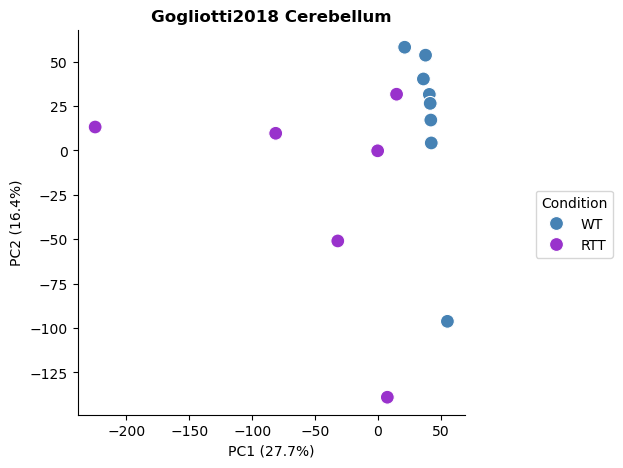

In [13]:
fig, ax = plt.subplots(figsize = (5, 5))
palette_pca = {'WT' : 'steelblue',
               'RTT' : 'darkorchid'}

pca_df['Condition'] = pca_df['Condition'].replace({'Ctrl' : 'WT'})
sns.scatterplot(data = pca_df, x = 'PC1', y = 'PC2', palette = palette_pca, hue = 'Condition', s = 100)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)") # f-string é uma forma moderna de formatar strings em python, valor da variância * 100 para meter em percentagem e dps coloca só com uma casa decimal
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("Gogliotti2018 Cerebellum", fontweight = 'bold', fontsize = 12)
ax.legend(title = 'Condition', bbox_to_anchor = (1.4, 0.6))
sns.despine()
plt.show()


Boxplot

In [14]:
# Assemble the new table
log2cpm_df.insert(0, 'Gene', genes)
goi_df = log2cpm_df[log2cpm_df['Gene'].isin(genes_of_interest)]

long_df = goi_df.melt(id_vars = 'Gene', var_name = 'Sample_Name', value_name = 'log2(CPM)')
long_df = long_df.merge(clinical_data, on = 'Sample_Name', how = 'left')

print(clinical_data.head())

# Assemble the plot

fig, ax = plt.subplots(figsize = (12, 12))

palette_boxplot = {'RTT' : 'tomato',
                   'Ctrl' : 'steelblue'}

sns.boxplot(data = long_df, x = 'Gene', y = 'log2(CPM)', hue = 'Condition', palette = palette_boxplot,
                fliersize = 2, linewidth = 2)

ax.set_title('Boxplot - Genes - Cerebellum', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Genes')
ax.set_ylabel('log2(CPM)')
ax.tick_params(axis = 'x', rotation = 45)



TypeError: only list-like objects are allowed to be passed to isin(), you passed a `NoneType`